In [106]:
from astropy.io import fits
from astropy.timeseries import LombScargle

import os
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

import scipy.stats as ss
from scipy.io import readsav
from scipy.optimize import curve_fit
from sklearn.decomposition import PCA

from tqdm import tqdm

import tools as t

In [107]:
# SIMULATED DATA
# load simulation files
path_sims = '../data/sim_series/'
serie = 1
spectra_sim = fits.getdata(path_sims + f'flux_norm_6173_lionel_tau1_spatialscaling1_sansrotation_serie{serie}.fits')
rv_data_sim = readsav(path_sims + f'res_rv_bis_6173_lionel_tau1_scaling1_sansrot_serie{serie}.sav')

# OBSERVED DATA
# load HARPS-N files
path_dace = '../data/dace_sun/'
direc = 'Jan2017/'  # sub directory where the specific data is
# iterate over saved files in direc
# save names (observation dates) of the files
dates_files = []
for entry in os.scandir(path_dace + direc):
    if entry.name != 'spectra.txt' and entry.name != 'CCF':
        dates_files.append(entry.name)

dates_files = sorted(dates_files, key=lambda d: datetime.strptime(d, "%Y-%m-%d"))  # sort

In [108]:
# OBSERVED DATA
# make a list of the available files that end by A.fits (s1d)
files_list = []
for d in dates_files:  # iterate over directories
    date_path = path_dace + direc + d + '/'
    files = os.scandir(date_path)  # files in directory
    files = list(files)
    files = [d + '/' + i.name for i in files]  # list of file names
    files_list.extend(files)  # save file names
files_list = [s for s in files_list if s.endswith('A.fits')]  # keep only the files that end by A.fits
files_list = np.array(files_list)
print(f's1d files: {len(files_list)}')

# make a list of the available files that end by A.fits (CCF)
files_ccf_list = []
for d in dates_files:  # iterate over directories
    date_path = path_dace + direc + 'CCF/' + d + '/'
    files = os.scandir(date_path)  # files in directory
    files = list(files)
    files = [d + '/' + i.name for i in files]  # list of file names
    files_ccf_list.extend(files)  # save file names
files_ccf_list = np.array(files_ccf_list)
print(f'ccf files: {len(files_ccf_list)}')

# keep only ccf files that have a corresponding s1d file
files_s1d = []
files_ccf = []

for i in files_ccf_list:
    s1d_file = i.replace('CCF', 'S1D')
    if s1d_file in files_list:
        files_s1d.append(s1d_file)
        files_ccf.append(i)

files_s1d = np.array(files_s1d)
files_ccf = np.array(files_ccf)
print(f'Number of usable files: {len(files_s1d)}')

s1d files: 294
ccf files: 333
Number of usable files: 250


In [109]:
# OBSERVED DATA
# recover dates only
dates = []
for f in files_ccf:
    path_file = path_dace + direc + 'CCF/' + f
    hdul = fits.open(path_file)
    hdr0 = hdul[0].header
    dates.append(datetime.strptime(hdr0['DATE-OBS'], '%Y-%m-%dT%H:%M:%S.%f'))

dates = np.array(dates)

In [110]:
c = 3e8
# SIMULATED DATA
# extract data
wl_sim = rv_data_sim['lambd']
rv_sim = rv_data_sim['rv_correl']
template_sim = rv_data_sim['flux_moy']
times_sim = np.arange(0, len(spectra_sim) * 144, 144) / 60 / 24  # time in days

# get only one month of data, to compare with observed data
n_days = 31
spectra_sim = spectra_sim[times_sim < n_days]
rv_sim = rv_sim[times_sim < n_days]
times_sim = times_sim[times_sim < n_days]
times_sim_sec = times_sim * 86400

In [111]:
step_days = 4  # divide de month in steps of this size
n_days = 31
day_ranges = t.build_day_ranges(step_days, n_days)
day_ranges = day_ranges[:-1]  # take out last element so all have the same size (avoids plotting problems at the end)


# SIMULATED DATA
spectra_sim_grouped = {}
rv_sim_grouped = {}

range_ind = 0
for i in range(len(times_sim)):
    days = day_ranges[range_ind]
    if times_sim[i] > days[1]:
        if range_ind + 1 >= len(day_ranges):
            break
        range_ind += 1
    if range_ind not in spectra_sim_grouped.keys():
        spectra_sim_grouped[range_ind] = [spectra_sim[i]]
        rv_sim_grouped[range_ind] = [rv_sim[i]]
    else:
        spectra_sim_grouped[range_ind].append(spectra_sim[i])
        rv_sim_grouped[range_ind].append(rv_sim[i])

# OBSERVED DATA
files_grouped_s1d = {}
files_grouped_ccf = {}

for i in range(len(dates)):
    day = dates[i].day
    for j in day_ranges:
        if j[0] <= day <= j[1]:
            group = day_ranges.index(j)
            if group not in files_grouped_s1d.keys():
                files_grouped_s1d[group] = [files_s1d[i]]
                files_grouped_ccf[group] = [files_ccf[i]]
            else:
                files_grouped_s1d[group].append(files_s1d[i])
                files_grouped_ccf[group].append(files_ccf[i])

day_ranges = np.array(day_ranges)

In [112]:
# OBSERVED DATA
# extract data from s1d files
spectra = {}
err = {}

for group in files_grouped_s1d.keys():
    for f in files_grouped_s1d[group]:
        path_file = path_dace + direc + f
        hdul = fits.open(path_file)  # open file
        if group not in spectra.keys():
            spectra[group] = [hdul[1].data['flux']]  # save spectrum
            err[group] = [hdul[1].data['error']]  # save flux error
        else:
            spectra[group].append(hdul[1].data['flux'])  # save spectrum
            err[group].append(hdul[1].data['error'])  # save flux error

# extract data from ccf files
rv = {}
dates = {}
julian_dates = {}

for group in files_grouped_ccf.keys():
    for f in files_grouped_ccf[group]:
        path_file = path_dace + direc + 'CCF/' + f
        hdul = fits.open(path_file)  # open file
        hdr0 = hdul[0].header
        if group not in rv.keys():
            rv[group] = [hdr0['TNG QC CCF RV']]  # save rv
            dates[group] = [datetime.strptime(hdr0['DATE-OBS'], '%Y-%m-%dT%H:%M:%S.%f')]  # save date
            julian_dates[group] = [hdr0['MJD-OBS']]  # save julian date
        else:
            rv[group].append(hdr0['TNG QC CCF RV'])  # save rv
            dates[group].append(datetime.strptime(hdr0['DATE-OBS'], '%Y-%m-%dT%H:%M:%S.%f'))  # save date
            julian_dates[group].append(hdr0['MJD-OBS'])  # save julian date

In [113]:
# OBSERVED DATA
# extract wavelength (same for all files)
filename = path_dace + direc + files_list[0]
s1d = fits.getdata(filename, 1)  # load file
wl = s1d['wavelength_air']  # angstrom

# get absorption line
line_min, line_max = 6173, 6173.7
line_indices = np.where((line_min < wl) & (wl < line_max))[0]

wl = wl[line_indices]
spectra_line = {}

for i in spectra.keys():
    s = np.array(spectra[i])
    s = s[:, line_indices]
    s = np.array([s[i] / max(s[i]) for i in range(len(s))])
    spectra_line[i] = s

spectra = spectra_line

In [114]:
spectra_sim_grouped.keys(), spectra.keys()

(dict_keys([0, 1, 2, 3, 4, 5, 6]), dict_keys([0, 1, 2, 3, 4, 5, 6]))

In [115]:
# take out projection over the velocity vector

# SIMULATED DATA
mean_spec_sim = {}
S_f_sim = {}
D_sim = {}
spectra_sim_centered = {}

for i in spectra_sim_grouped.keys():
    # SIMULATED DATA
    s = np.array(spectra_sim_grouped[i])
    mean_spec_sim[i] = np.mean(s, axis=0)  # save mean spectrum
    sub_v = t.subtract_v(wl_sim, s)
    S_f_sim[i] = sub_v[0]
    D_sim[i] = sub_v[1]
    spectra_sim_centered[i] = t.double_centering(sub_v[0])

# OBSERVED DATA
mean_spec = {}
S_f = {}
D = {}
spectra_centered = {}

for i in spectra.keys():
    s = np.array(spectra[i])
    mean_spec[i] = np.mean(s, axis=0)  # save mean spectrum
    sub_v = t.subtract_v(wl, s)
    S_f[i] = sub_v[0]
    D[i] = sub_v[1]
    spectra_centered[i] = t.double_centering(sub_v[0])

## Apply PCA

In [116]:
# apply PCA to the centered spectra matrix
# SIMULATED DATA
n_components = 10
loadings_sim = {}
scores_sim = {}
for i in spectra_sim_centered.keys():
    pca_flux = PCA(n_components=n_components)
    pcs  = pca_flux.fit_transform(spectra_sim_centered[i])
    loadings_sim[i] = pca_flux.components_
    scores_sim[i] = np.array([pcs[:, j] for j in range(n_components)])

# OBSERVED DATA
loadings = {}
scores = {}
for i in spectra_centered.keys():
    pca_flux = PCA(n_components=n_components)
    pcs  = pca_flux.fit_transform(spectra_centered[i])
    loadings[i] = pca_flux.components_
    scores[i] = np.array([pcs[:, j] for j in range(n_components)])

In [117]:
# periodograms and correlation coefficient
# SIMULATED DATA
periodograms_sim = {}
corr_sim = {}
for i in scores_sim.keys():
    periodograms_sim[i] = [t.calculate_periodogram(times_sim_sec, scores_sim[i][j]) for j in range(n_components)]
    corr_sim[i] = np.array([ss.pearsonr(scores_sim[i][j], rv_sim_grouped[i])[0] for j in range(n_components)])

# OBSERVED DATA
periodograms = {}
corr = {}
for i in scores.keys():
    periodograms[i] = [LombScargle(julian_dates[i], scores[i][j]).autopower() for j in range(n_components)]  # returns frequency in days^-1
    corr[i] = np.array([ss.pearsonr(scores[i][j], rv[i])[0] for j in range(n_components)])

/tmp/ipykernel_2719305/225247596.py:14: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  corr[i] = np.array([ss.pearsonr(scores[i][j], rv[i])[0] for j in range(n_components)])


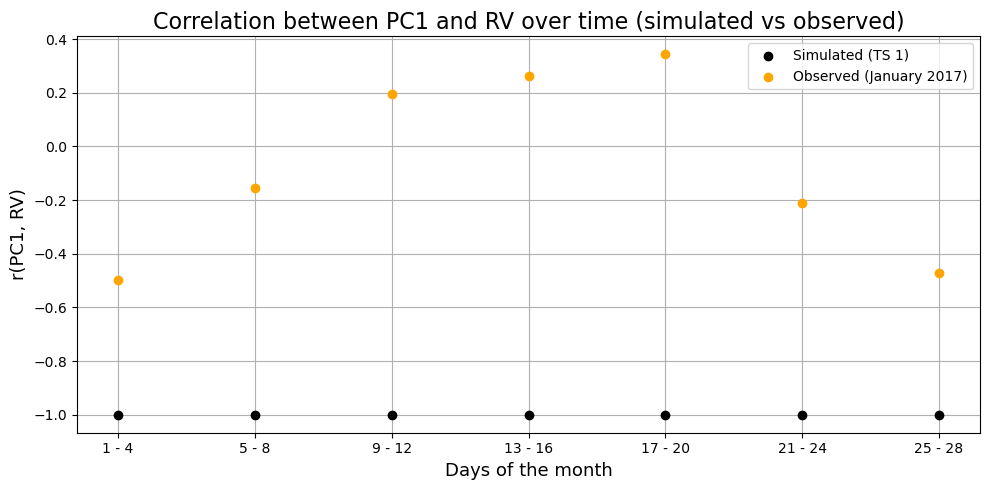

In [119]:
# plot PC1-RV correlation over time
corr_sim_pc1 = [i[0] for i in corr_sim.values()]  # simulated
corr_pc1 = [i[0] for i in corr.values()]  # observed

# x positions = midpoint of each time range
x = np.array([np.mean(i) for i in day_ranges])
# x tick labels
xlabels = [f'{start} - {end}' for start, end in day_ranges]

# plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.grid()
ax.scatter(x, corr_sim_pc1, color='k', label=f'Simulated (TS {serie})', zorder=2)
ax.scatter(x[list(spectra.keys())], corr_pc1, color='orange', label='Observed (January 2017)', zorder=2)

# set ticks and labels
ax.set_xticks(x)
ax.set_xticklabels(xlabels, rotation=0)

ax.set_xlabel('Days of the month', size=13)
ax.set_ylabel('r(PC1, RV)', size=13)
ax.set_title('Correlation between PC1 and RV over time (simulated vs observed)', size=16)

plt.legend()
plt.tight_layout()
plt.show()